# Inventory Management Implementation Notebook

Start-to-finish implementation for inventory analytics on `ecommerce.db` with:
- ABC/XYZ segmentation
- Reorder Point (ROP) and EOQ recommendations
- Inventory-focused exploratory analysis
- Agent-ready recommendation outputs

## 1. Set Up Environment and Imports

In [1]:
import os
import sqlite3
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')

print('Python modules loaded successfully')
print('pandas', pd.__version__)
print('numpy', np.__version__)

Python modules loaded successfully
pandas 3.0.1
numpy 2.4.3


## 2. Define Configuration and Constants

In [4]:
@dataclass
class InventoryConfig:
    db_path: str = os.getenv('DB_PATH', '/home/mikolaj/OptimAIze/ecommerce.db')
    output_dir: str = 'artifacts/inventory_analysis'
    planning_horizon_days: int = 30
    lead_time_days: int = 7
    service_level: float = 0.95
    service_z: float = 1.645  # Approx z-score for 95% cycle service level
    demand_anchor_mode: str = 'last_nonzero'  # 'latest' or 'last_nonzero'

    # ABC class-based EOQ assumptions
    order_cost_by_abc: Dict[str, float] = None
    holding_cost_rate_by_abc: Dict[str, float] = None

    def __post_init__(self):
        if self.order_cost_by_abc is None:
            self.order_cost_by_abc = {'A': 70.0, 'B': 50.0, 'C': 35.0}
        if self.holding_cost_rate_by_abc is None:
            self.holding_cost_rate_by_abc = {'A': 0.30, 'B': 0.24, 'C': 0.18}

cfg = InventoryConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
cfg

InventoryConfig(db_path='/home/mikolaj/OptimAIze/ecommerce.db', output_dir='artifacts/inventory_analysis', planning_horizon_days=30, lead_time_days=7, service_level=0.95, service_z=1.645, demand_anchor_mode='last_nonzero', order_cost_by_abc={'A': 70.0, 'B': 50.0, 'C': 35.0}, holding_cost_rate_by_abc={'A': 0.3, 'B': 0.24, 'C': 0.18})

## 3. Load Input Data

In [8]:
def load_input_tables(config: InventoryConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not Path(config.db_path).exists():
        raise FileNotFoundError(f'Database not found: {config.db_path}')

    conn = sqlite3.connect(config.db_path)
    try:
        inv = pd.read_sql('SELECT product_id, current_stock, price FROM inventory', conn)
        sales = pd.read_sql('SELECT product_id, date, sales, revenue, price, stock FROM sales_aggregated', conn)
    finally:
        conn.close()

    sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
    for col in ['sales', 'revenue', 'price', 'stock']:
        if col in sales.columns:
            sales[col] = pd.to_numeric(sales[col], errors='coerce')

    inv['current_stock'] = pd.to_numeric(inv['current_stock'], errors='coerce')
    inv['price'] = pd.to_numeric(inv['price'], errors='coerce')

    return inv, sales

inventory_df, sales_df = load_input_tables(cfg)
print('inventory rows:', len(inventory_df))
print('sales rows:', len(sales_df))
display(inventory_df.head(3))
display(sales_df.head(3))

inventory rows: 649
sales rows: 487986


,product_id,current_stock,price
0,P0001,29,8.25
1,P0002,2,283.74
2,P0004,13,4.53


,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0


## 4. Implement Core Functions

In [9]:
def build_product_demand_features(
    sales: pd.DataFrame,
    horizon_days: int = 30,
    anchor_mode: str = 'last_nonzero',
) -> pd.DataFrame:
    """Aggregate per-product demand features for inventory policy decisions."""
    clean = sales.copy()
    clean = clean.dropna(subset=['product_id', 'date'])

    # Robust anchor to avoid zero-demand tail periods flattening all policy outputs.
    if anchor_mode == 'last_nonzero':
        nonzero = clean[clean['sales'] > 0]
        anchor_date = nonzero['date'].max() if not nonzero.empty else clean['date'].max()
    else:
        anchor_date = clean['date'].max()

    horizon_start = anchor_date - pd.Timedelta(days=horizon_days - 1)
    horizon_df = clean[(clean['date'] >= horizon_start) & (clean['date'] <= anchor_date)].copy()
    history_df = clean.copy()

    # Exact mean and std over `horizon_days` including 0-sales days:
    daily_sales = horizon_df.groupby(['product_id', 'date'])['sales'].sum().reset_index()
    
    # Pivot to have dates as columns, products as rows, fill missing with 0
    pivot_sales = daily_sales.pivot(index='product_id', columns='date', values='sales').fillna(0)
    
    # Ensure all days in horizon are present in columns
    all_days = pd.date_range(start=horizon_start, end=anchor_date)
    for day in all_days:
        if day not in pivot_sales.columns:
            pivot_sales[day] = 0.0

    # Calculate true mean and std per product across the exact window
    near_term = pd.DataFrame({
        'product_id': pivot_sales.index,
        'demand_sum_h': pivot_sales.sum(axis=1).values,
        'demand_mean_daily': pivot_sales.mean(axis=1).values,
        'demand_std_daily': pivot_sales.std(axis=1, ddof=1).values,
        'active_days': (pivot_sales > 0).sum(axis=1).values
    })

    # Ensure all historical products are present
    all_products = pd.DataFrame({'product_id': history_df['product_id'].unique()})
    near_term = all_products.merge(near_term, on='product_id', how='left').fillna(0)

    # Lifespan metrics for accurate historical fallback
    annual = history_df.groupby('product_id', as_index=False).agg(
        annual_sales=('sales', 'sum'),
        annual_revenue=('revenue', 'sum'),
        first_sale=('date', 'min'),
        last_sale=('date', 'max')
    )

    features = near_term.merge(annual, on='product_id', how='left')
    features['demand_std_daily'] = features['demand_std_daily'].fillna(0)
    features['demand_mean_daily'] = features['demand_mean_daily'].fillna(0)
    features['active_days'] = features['active_days'].fillna(0)
    features['annual_sales'] = features['annual_sales'].fillna(0)

    # Fallback: if 30-day mean is 0, use proportional historical average based on actual product lifespan
    lifespan_days = (features['last_sale'] - features['first_sale']).dt.days + 1
    lifespan_days = np.maximum(lifespan_days, 1) # Prevent div by 0
    
    historical_daily_avg = features['annual_sales'] / lifespan_days
    
    features['demand_mean_daily'] = np.where(
        features['demand_mean_daily'] > 0,
        features['demand_mean_daily'],
        historical_daily_avg
    )

    # CV behavior: gracefully handle zero mean or std
    features['cv'] = np.where(
        features['demand_mean_daily'] > 0,
        features['demand_std_daily'] / features['demand_mean_daily'],
        np.where(features['demand_std_daily'] > 0, 9.99, 0.0),
    )
    return features

def classify_abc(features: pd.DataFrame) -> pd.DataFrame:
    """Assign ABC classes using cumulative share of annual revenue."""
    df = features.copy()
    df['annual_revenue'] = df['annual_revenue'].fillna(0)
    df = df.sort_values('annual_revenue', ascending=False).reset_index(drop=True)

    total = max(df['annual_revenue'].sum(), 1e-9)
    df['cum_revenue_share'] = df['annual_revenue'].cumsum() / total

    df['abc_class'] = np.select(
        [df['cum_revenue_share'] <= 0.80, df['cum_revenue_share'] <= 0.95],
        ['A', 'B'],
        default='C'
    )
    return df

def classify_xyz(df: pd.DataFrame) -> pd.DataFrame:
    """Assign XYZ classes by coefficient of variation thresholds."""
    out = df.copy()
    out['xyz_class'] = np.select(
        [out['cv'] < 0.5, out['cv'] < 1.0],
        ['X', 'Y'],
        default='Z'
    )
    out['policy_code'] = out['abc_class'] + out['xyz_class']
    return out

def compute_rop_eoq(df: pd.DataFrame, inv: pd.DataFrame, config: InventoryConfig) -> pd.DataFrame:
    """Compute ROP/EOQ/reorder quantity using class-based assumptions."""
    out = df.merge(inv[['product_id', 'current_stock', 'price']], on='product_id', how='left', suffixes=('', '_inv'))

    # Prefer inventory price if present; fallback to sales-derived value
    out['unit_price'] = out['price'].where(out['price'].notna(), 0.0)

    out['daily_demand'] = out['demand_mean_daily'].clip(lower=0)
    out['demand_std_daily'] = out['demand_std_daily'].fillna(0).clip(lower=0)

    out['safety_stock'] = config.service_z * out['demand_std_daily'] * np.sqrt(config.lead_time_days)
    out['rop'] = (out['daily_demand'] * config.lead_time_days) + out['safety_stock']

    out['annual_demand'] = out['daily_demand'] * 365.0
    out['order_cost'] = out['abc_class'].map(config.order_cost_by_abc).fillna(50.0)
    out['holding_cost'] = (
        out['abc_class'].map(config.holding_cost_rate_by_abc).fillna(0.24) *
        out['unit_price'].clip(lower=0.01)
    )

    out['eoq'] = np.sqrt((2.0 * out['annual_demand'] * out['order_cost']) / out['holding_cost'])
    out['eoq'] = out['eoq'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)

    out['current_stock'] = out['current_stock'].fillna(0).clip(lower=1) # Prevent 0 stock globally
    out['qty_to_rop'] = (out['rop'] - out['current_stock']).clip(lower=0)

    # Reorder only when below ROP; then use the larger of gap-to-ROP and EOQ.
    out['reorder_qty'] = np.where(
        out['current_stock'] < out['rop'],
        np.ceil(np.maximum(out['qty_to_rop'], out['eoq'])),
        0.0
    ).astype(int)

    out['priority'] = np.select(
        [out['current_stock'] < out['rop'], out['policy_code'].isin(['AX', 'AY'])],
        ['REORDER_NOW', 'MONITOR_CLOSELY'],
        default='NORMAL'
    )

    out['priority_rank'] = out['priority'].map({'REORDER_NOW': 0, 'MONITOR_CLOSELY': 1, 'NORMAL': 2}).fillna(3).astype(int)
    out['stock_cover_days'] = np.where(
        out['daily_demand'] > 0,
        out['current_stock'] / out['daily_demand'],
        np.nan,
    )
    out['overstock_flag'] = np.where(
        out['daily_demand'] > 0,
        out['stock_cover_days'] > 90,
        False,
    )
    
    out['reasoning'] = (
        'Policy=' + out['policy_code'].astype(str) +
        '; stock=' + out['current_stock'].round(1).astype(str) +
        '; rop=' + out['rop'].round(1).astype(str) +
        '; eoq=' + out['eoq'].round(1).astype(str)
    )

    return out

features_df = build_product_demand_features(
    sales_df,
    cfg.planning_horizon_days,
    anchor_mode=cfg.demand_anchor_mode,
 )
classified_df = classify_xyz(classify_abc(features_df))
final_df = compute_rop_eoq(classified_df, inventory_df, cfg)
print('Final workflow calculations complete. Total rows:', len(final_df))
display(final_df.head(5))

Final workflow calculations complete. Total rows: 649


,product_id,demand_sum_h,demand_mean_daily,demand_std_daily,active_days,annual_sales,annual_revenue,first_sale,last_sale,cv,...,order_cost,holding_cost,eoq,qty_to_rop,reorder_qty,priority,priority_rank,stock_cover_days,overstock_flag,reasoning
0,P0103,18863.0,628.766667,115.815157,30.0,881634.0,2670199.663,2017-01-02,2019-12-29,0.184194,...,70.0,1.077,5461.945387,0.0,0,MONITOR_CLOSELY,1,8.971532,False,Policy=AX; stock=5641; rop=4905.4; eoq=5461.9
1,P0129,1676.0,55.866667,54.114013,30.0,58837.0,1328199.720,2017-01-02,2019-12-29,0.968628,...,70.0,8.697,572.930701,0.0,0,MONITOR_CLOSELY,1,12.905728,False,Policy=AY; stock=721; rop=626.6; eoq=572.9
2,P0500,10095.0,336.500000,67.893807,30.0,161805.0,1300795.320,2017-01-02,2019-12-29,0.201765,...,70.0,2.850,2456.295171,0.0,0,MONITOR_CLOSELY,1,10.805349,False,Policy=AX; stock=3636; rop=2651.0; eoq=2456.3
3,P0428,714.0,23.800000,5.761944,30.0,40303.0,1065853.790,2017-10-03,2019-12-29,0.242098,...,70.0,9.222,363.150269,0.0,0,MONITOR_CLOSELY,1,10.000000,False,Policy=AX; stock=238; rop=191.7; eoq=363.2
4,P0182,2507.0,83.566667,24.142798,30.0,43586.0,823723.090,2019-02-01,2019-12-29,0.288905,...,70.0,6.750,795.380800,0.0,0,MONITOR_CLOSELY,1,11.487834,False,Policy=AX; stock=960; rop=690.0; eoq=795.4


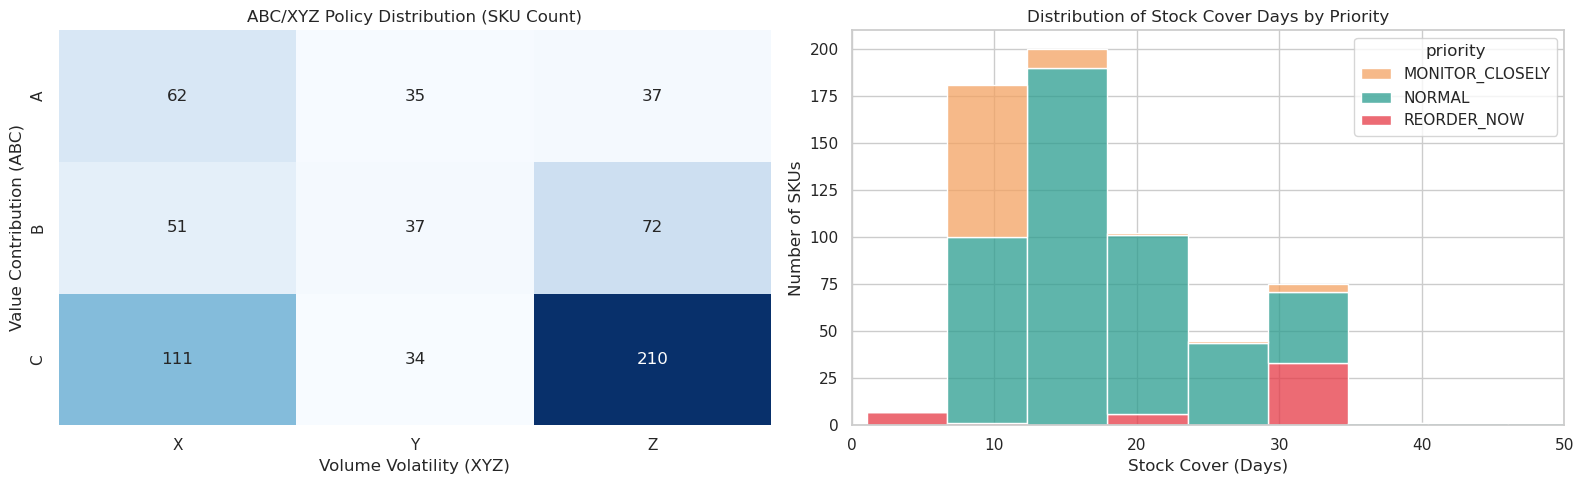

Most Critical Reorder Candidates:


,product_id,policy_code,current_stock,rop,eoq,reorder_qty,stock_cover_days,priority
542,P0299,CX,12,12.403846,283.024180,284,6.772093,REORDER_NOW
510,P0105,CX,10,16.582524,220.755206,221,4.221311,REORDER_NOW
526,P0728,CX,6,12.609256,148.401675,149,3.330886,REORDER_NOW
611,P0384,CX,1,6.820513,131.484240,132,1.026316,REORDER_NOW
447,P0360,CX,5,5.969178,68.296550,69,5.863454,REORDER_NOW
613,P0172,CZ,1,1.027944,39.581760,40,30.000000,REORDER_NOW
153,P0602,BZ,2,2.027999,36.718612,37,20.000000,REORDER_NOW
603,P0745,CX,2,6.533333,36.399826,37,2.142857,REORDER_NOW
626,P0289,CZ,1,1.027944,36.715125,37,30.000000,REORDER_NOW
471,P0278,CZ,2,2.027999,34.450348,35,20.000000,REORDER_NOW


In [12]:
# 5. Visualizing Inventory Health and Policy Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

# 1. Policy Distribution Matrix (Heatmap)
plt.subplot(1, 2, 1)
matrix_data = final_df.groupby(['abc_class', 'xyz_class']).size().reset_index(name='count')
pivot_matrix = matrix_data.pivot(index='abc_class', columns='xyz_class', values='count').fillna(0)
sns.heatmap(pivot_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('ABC/XYZ Policy Distribution (SKU Count)')
plt.xlabel('Volume Volatility (XYZ)')
plt.ylabel('Value Contribution (ABC)')

# 2. Stock Cover & Reorder Priority Distribution
plt.subplot(1, 2, 2)
# Filter unrealistic outliers for clarity
plot_df = final_df[final_df['stock_cover_days'] < 180].copy()
sns.histplot(
    data=plot_df,
    x='stock_cover_days',
    hue='priority',
    multiple='stack',
    palette={'REORDER_NOW': '#e63946', 'MONITOR_CLOSELY': '#f4a261', 'NORMAL': '#2a9d8f'},
    bins=30
)
plt.title('Distribution of Stock Cover Days by Priority')
plt.xlabel('Stock Cover (Days)')
plt.ylabel('Number of SKUs')
plt.xlim(0, 50)

plt.tight_layout()
plt.show()

# Display Top 10 Most Critical Reorder Candidates
print('Most Critical Reorder Candidates:')
display(
    final_df[['product_id', 'policy_code', 'current_stock', 'rop', 'eoq', 'reorder_qty', 'stock_cover_days', 'priority']]
    .sort_values(['priority', 'reorder_qty'], ascending=[False, False])
    .head(10)
)

### Additional Inventory Exploratory Analysis

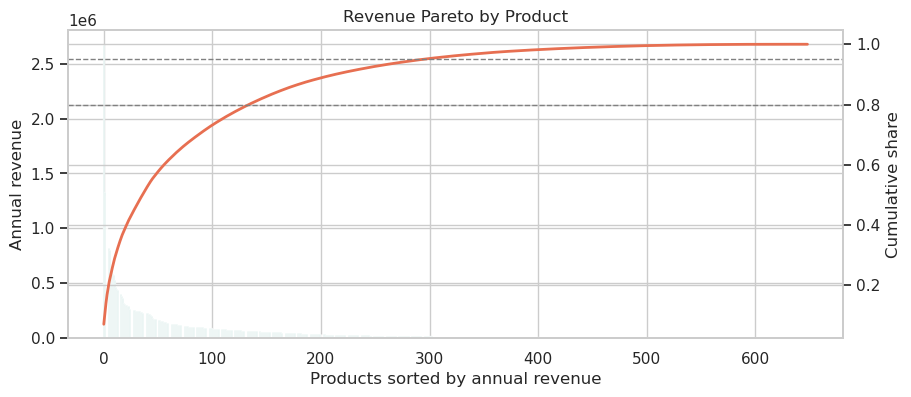

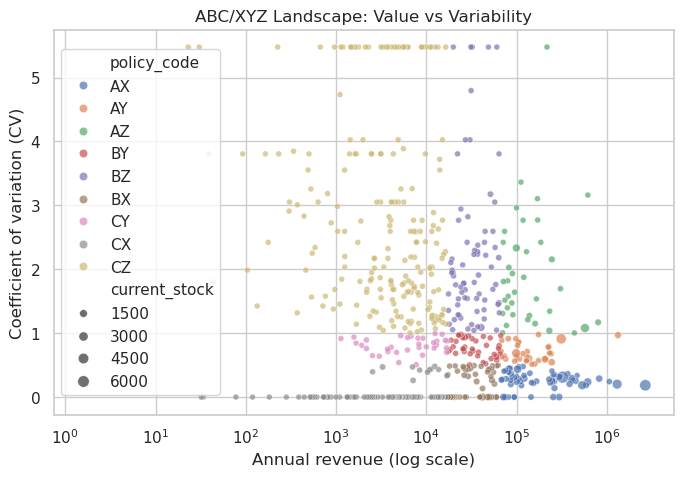

Slow mover SKU count: 87


,product_id,daily_demand,current_stock,stock_cover_days
6,P0316,0.065200,6,92.02454
42,P0438,0.033333,45,1350.00000
138,P0474,0.066667,2,30.00000
145,P0397,0.033333,1,30.00000
170,P0398,0.033333,1,30.00000
211,P0148,0.033333,12,360.00000
214,P0669,0.033333,1,30.00000
258,P0233,0.066667,2,30.00000
272,P0571,0.033333,1,30.00000
299,P0265,0.033333,20,600.00000


In [13]:
# Revenue Pareto (ABC intuition)
pareto = (
    final_df[['product_id', 'annual_revenue']]
    .sort_values('annual_revenue', ascending=False)
    .reset_index(drop=True)
)
pareto['cum_share'] = pareto['annual_revenue'].cumsum() / max(pareto['annual_revenue'].sum(), 1e-9)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(pareto.index, pareto['annual_revenue'], color='#2a9d8f', alpha=0.8)
ax1.set_title('Revenue Pareto by Product')
ax1.set_xlabel('Products sorted by annual revenue')
ax1.set_ylabel('Annual revenue')

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['cum_share'], color='#e76f51', linewidth=2)
ax2.axhline(0.80, linestyle='--', color='gray', linewidth=1)
ax2.axhline(0.95, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Cumulative share')
plt.show()

# ABC/XYZ scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=final_df,
    x='annual_revenue',
    y='cv',
    hue='policy_code',
    size='current_stock',
    alpha=0.7
)
plt.xscale('log')
plt.title('ABC/XYZ Landscape: Value vs Variability')
plt.xlabel('Annual revenue (log scale)')
plt.ylabel('Coefficient of variation (CV)')
plt.show()

# Dead stock / slow movers
slow_movers = final_df[final_df['daily_demand'] <= final_df['daily_demand'].median() / 10.0]
print('Slow mover SKU count:', len(slow_movers))
display(slow_movers[['product_id', 'daily_demand', 'current_stock', 'stock_cover_days']].head(20))

## 7. Inspect Output and Persist Results

In [16]:
def generate_procurement_recommendations(df: pd.DataFrame, config: InventoryConfig) -> pd.DataFrame:
    """Generate actionable purchase order recommendations for the next 30 days."""
    
    # Filter items that require action: either below ROP or high-priority monitors
    action_items = df[
        (df['current_stock'] < df['rop']) | 
        (df['priority'].isin(['REORDER_NOW', 'MONITOR_CLOSELY']))
    ].copy()
    
    # Add procurement-specific calculations
    action_items['lead_time_days'] = config.lead_time_days
    action_items['forecasted_30day_demand'] = action_items['demand_mean_daily'] * 30
    action_items['stock_after_30days'] = action_items['current_stock'] - action_items['forecasted_30day_demand']
    
    # Recommend order quantity: use EOQ if in normal cycle, else fill to ROP + 30-day buffer
    action_items['recommended_qty'] = np.where(
        action_items['current_stock'] < action_items['rop'],
        np.ceil(action_items['rop'] + (action_items['demand_mean_daily'] * 30) - action_items['current_stock']),
        np.ceil(action_items['eoq'])
    ).astype(int)
    
    # Cost estimation
    action_items['estimated_order_cost'] = action_items['recommended_qty'] * action_items['unit_price'].clip(lower=0.01)
    
    # Expected arrival date based on lead time
    action_items['expected_arrival_date'] = pd.Timestamp.now() + pd.Timedelta(days=config.lead_time_days)
    
    # Create recommendation record
    recommendations = action_items[[
        'product_id',
        'policy_code',
        'abc_class',
        'xyz_class',
        'current_stock',
        'rop',
        'eoq',
        'recommended_qty',
        'unit_price',
        'estimated_order_cost',
        'demand_mean_daily',
        'forecasted_30day_demand',
        'stock_after_30days',
        'lead_time_days',
        'expected_arrival_date',
        'priority',
        'priority_rank',
        'stock_cover_days',
        'reasoning'
    ]].copy()
    
    # Sort by priority and then by order value (descending)
    recommendations = recommendations.sort_values(
        ['priority_rank', 'estimated_order_cost'],
        ascending=[True, False]
    ).reset_index(drop=True)
    
    return recommendations

# Generate procurement recommendations
procurement_recs = generate_procurement_recommendations(final_df, cfg)

print(f'Generated {len(procurement_recs)} purchase order recommendations\n')
print('Summary by Priority:')
print(procurement_recs.groupby('priority').agg({
    'product_id': 'count',
    'recommended_qty': 'sum',
    'estimated_order_cost': 'sum'
}).rename(columns={'product_id': 'sku_count', 'recommended_qty': 'total_units', 'estimated_order_cost': 'total_cost'}))

print('\n30-Day Purchase Plan Summary:')
print(f'Total SKUs to order: {len(procurement_recs)}')
print(f'Total units to order: {procurement_recs["recommended_qty"].sum():,.0f}')
print(f'Estimated total cost: ${procurement_recs["estimated_order_cost"].sum():,.2f}')

# Display top urgent orders
print('\nTop 15 Urgent Orders (REORDER_NOW):')
urgent = procurement_recs[procurement_recs['priority'] == 'REORDER_NOW'].head(15)
display(urgent[[
    'product_id', 'policy_code', 'current_stock', 'rop', 
    'recommended_qty', 'estimated_order_cost', 'stock_cover_days'
]])

# Save recommendations to CSV for procurement agent
output_path = f'{cfg.output_dir}/procurement_recommendations_30day.csv'
procurement_recs.to_csv(output_path, index=False)
print(f'\n✓ Procurement recommendations saved to: {output_path}')

# Summary table for quick reference
summary_output = procurement_recs[[
    'product_id', 'policy_code', 'priority', 'current_stock', 
    'recommended_qty', 'estimated_order_cost', 'expected_arrival_date'
]].copy()
summary_output.columns = ['Product ID', 'Policy', 'Priority', 'Current Stock', 
                           'Order Qty', 'Est. Cost ($)', 'Expected Arrival']
summary_path = f'{cfg.output_dir}/purchase_order_summary.csv'
summary_output.to_csv(summary_path, index=False)
print(f'✓ Purchase order summary saved to: {summary_path}')

Generated 144 purchase order recommendations

Summary by Priority:
                 sku_count  total_units  total_cost
priority                                           
MONITOR_CLOSELY         97       129566   609179.91
REORDER_NOW             47          401     9878.42

30-Day Purchase Plan Summary:
Total SKUs to order: 144
Total units to order: 129,967
Estimated total cost: $619,058.33

Top 15 Urgent Orders (REORDER_NOW):


,product_id,policy_code,current_stock,rop,recommended_qty,estimated_order_cost,stock_cover_days
0,P0745,CX,2,6.533333,33,3299.67,2.142857
1,P0122,CX,3,3.237785,15,899.25,6.485915
2,P0728,CX,6,12.609256,61,708.21,3.330886
3,P0360,CX,5,5.969178,27,700.65,5.863454
4,P0105,CX,10,16.582524,78,538.20,4.221311
5,P0384,CX,1,6.820513,36,288.00,1.026316
6,P0669,BZ,1,1.027944,2,273.42,30.000000
7,P0274,CZ,2,2.027999,4,239.60,20.000000
8,P0603,CZ,1,1.027944,2,189.94,30.000000
9,P0065,CZ,1,1.027944,2,186.10,30.000000



✓ Procurement recommendations saved to: artifacts/inventory_analysis/procurement_recommendations_30day.csv
✓ Purchase order summary saved to: artifacts/inventory_analysis/purchase_order_summary.csv
